# Psychometric Analysis

Equivalent to `BlackRockFileAnalyzer.m` + `VisPsychometricFunction.m` in MATLAB.  
Loads the exported `_trials.csv`, filters to valid trials, fits a logistic function,
and plots the psychometric curve with PSE and Threshold annotations.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize

## 1. Set path to exported CSV

In [3]:
# ── Edit this path ────────────────────────────────────────────────────────
CSV_PATH = (
    "/Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Data"
    "/Monkey Porthos/in_lab/export_data/2026-06-17"
    "/Blackrock_2026-06-17_trials.csv"
)
ANALYZE_TASK = "time_delay_experiment"
# ─────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} trials from {CSV_PATH.split('/')[-1]}")

Loaded 4617 trials from Blackrock_2026-06-17_trials.csv


## 2. Filter trials

Keep only: complete, correct task, valid choice (mirrors `BlackRockFileAnalyzer.m`).

In [4]:
complete = df['Save_complete'] == 1
correct_task = df['Task'] == ANALYZE_TASK
valid_choice = df['Choose_target'].notna()

selected = df[complete & correct_task & valid_choice].copy()

print(f"Complete           : {complete.sum()}")
print(f"Correct task       : {(complete & correct_task).sum()}")
print(f"Valid choice       : {(complete & correct_task & valid_choice).sum()}  ← using these")

Complete           : 4617
Correct task       : 4603
Valid choice       : 3097  ← using these


## 3. Build psychometric matrix

Columns: `[stimulus_dir, choice_rightward]`  
- `stimulus_dir = Requested_target_2_time_offset × Stimulus_direction` (signed asynchrony in ms)
- `choice_rightward = 1` if `Choose_leftright == 1` (chose rightward target)

In [5]:
stimulus     = selected['Requested_target_2_time_offset'].values
direction    = selected['Stimulus_direction'].values
choice_right = (selected['Choose_leftright'] == 1).astype(int).values

# Signed stimulus (positive = target 2 shown later when rightward)
stimulus_dir = stimulus * direction

print(f"Stimulus levels  : {np.unique(stimulus_dir)}")
print(f"N trials         : {len(stimulus_dir)}")

Stimulus levels  : [-200. -100.  -50.  -25.  -12.   -0.   12.   25.   50.  100.  200.]
N trials         : 3097


## 4. Bin proportions per stimulus level

In [6]:
levels = np.unique(stimulus_dir)
prop_right = np.array([
    choice_right[stimulus_dir == lvl].mean() for lvl in levels
])
n_per_level = np.array([
    (stimulus_dir == lvl).sum() for lvl in levels
])

for lvl, p, n in zip(levels, prop_right, n_per_level):
    print(f"  {lvl:+7.0f} ms  → P(right) = {p:.3f}  (n={n})")

     -200 ms  → P(right) = 0.070  (n=273)
     -100 ms  → P(right) = 0.076  (n=289)
      -50 ms  → P(right) = 0.142  (n=261)
      -25 ms  → P(right) = 0.220  (n=254)
      -12 ms  → P(right) = 0.285  (n=242)
       -0 ms  → P(right) = 0.461  (n=527)
      +12 ms  → P(right) = 0.622  (n=259)
      +25 ms  → P(right) = 0.682  (n=236)
      +50 ms  → P(right) = 0.825  (n=251)
     +100 ms  → P(right) = 0.888  (n=267)
     +200 ms  → P(right) = 0.937  (n=238)


## 5. Fit logistic psychometric function

 `fitglm(..., 'Distribution', 'binomial')` — MLE logistic regression on individual trials.

Model: `logit(P) = b0 + b1 * x`

- **PSE** = `-b0 / b1` — stimulus level where P(right) = 0.5
- **Threshold** = `1 / b1` — inverse slope (steepness of the curve)

In [7]:
def neg_log_likelihood(params, x, y):
    b0, b1 = params
    p = expit(b0 + b1 * x)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


try:
    result = minimize(neg_log_likelihood, [0.0, 0.01], args=(stimulus_dir, choice_right))
    b0, b1 = result.x
    pse       = -b0 / b1
    threshold =  1  / b1
    print(f"PSE       = {pse:.2f} ms")
    print(f"Threshold = {threshold:.2f} ms")
    fit_ok = True
except Exception as e:
    print(f"Fit failed: {e}")
    fit_ok = False

PSE       = 7.57 ms
Threshold = 47.42 ms


## 6. Plot psychometric curve

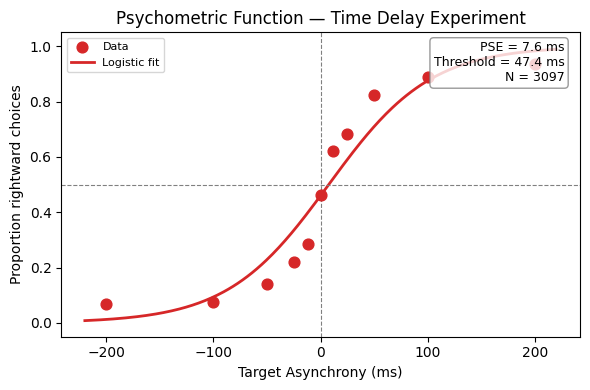

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

# Raw proportions
ax.scatter(
    levels, prop_right,
    color='tab:red', zorder=3, s=60,
    label='Data'
)

# Fitted curve
if fit_ok:
    x_fit = np.linspace(levels.min() - 20, levels.max() + 20, 300)
    y_fit = expit(b0 + b1 * x_fit)
    ax.plot(x_fit, y_fit, color='tab:red', linewidth=2, label='Logistic fit')

# Reference lines
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0.0, color='gray', linestyle='--', linewidth=0.8)

# Annotate PSE / threshold
if fit_ok:
    N = len(stimulus_dir)
    ax.text(
        0.97, 0.97,
        f"PSE = {pse:.1f} ms\nThreshold = {threshold:.1f} ms\nN = {N}",
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8)
    )

ax.set_xlabel('Target Asynchrony (ms)')
ax.set_ylabel('Proportion rightward choices')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Psychometric Function — Time Delay Experiment')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()